In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# импорт из библиотеки scipy.optimize функции curve_fit
from scipy.optimize import curve_fit


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения аппроксимирующей функции
# вида a*exp(-b*x+c)
def func(x, a, b, c):
    return a * np.exp(-b * x) + c

In [3]:
# Ячейка № 3

# задание функции, возвращающей
# значения аппроксимирующей функции
# вида a/(b*x+c)
def func_dZ(x, a, b, c):
    return a / (b * x + c)

In [4]:
# Ячейка № 4

# задание функции, возвращающую
# единичную реализацию зависимости
# числа частиц, находящихся в левой
# половине ящика, от времени
def Particle_at_the_left(N_Particle, N_Step):
    # N_Particle - число частиц в левой
    #              половине ящика
    # N_step - длина единичной реализации

    # инициализация массива, используемого для
    # хранения <<мгновенных>> значений зависимости
    # <<число частиц в левой половине ящика от времени>>
    Left_N = np.zeros(N_Step + 1)

    # размещение нулевом элементе массива Left_N
    # числа частиц, находящихся в левой половине ящика
    # в момент времени t = 0
    Left_N[0] = N_Particle

    # вычисление <<мгновенных>> значений зависимости
    # <<число частиц в левой половине ящика от времени>>
    for i in range(1, N_Step + 1):
        Prob = Left_N[i - 1] / N_Particle
        if Prob >= random.uniform(0, 1):
            Left_N[i] = Left_N[i - 1] - 1
        else:
            Left_N[i] = Left_N[i - 1] + 1

    return Left_N

In [5]:
# Ячейка № 5

# задание функции, возвращающей
# ансамбль <<мгновенных>> значений зависимости
# <<число частиц в левой половине ящика от времени>>
def Ensamble(N_Trial, N_Particle, N_Step):
    # N_Trial - число независимых реализаций
    # N_Particle - число частиц в левой
    #              половине ящика
    # N_step - длина единичной реализации

    # инициализация массива, используемого
    # для размещения ансамбля реализаций
    z = np.zeros([N_Step + 1, N_Trial])
    for i in range(N_Trial):
        Z = Particle_at_the_left(N_Particle, N_Step)
        z[:, i] = Z

    return z

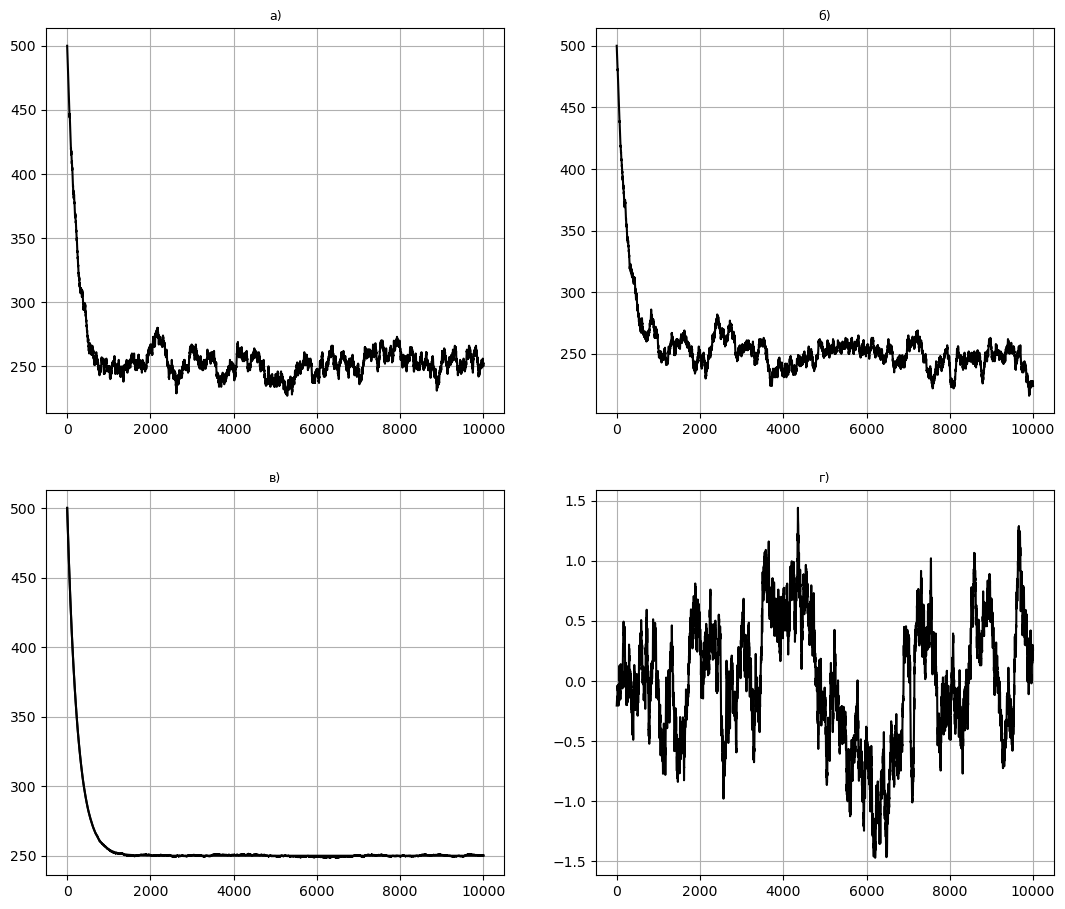

In [ ]:
# Ячейка № 6

# моделирование процесса релаксации
# статистической системы
# к равновесному состоянию

# задание числа частиц
# моделируемой системы
N_Particle = 500

#  задание длины единичной реализации
N_Step = 10000

# задание числа независимых испытаний
N_Trial = 400

# вычисление ансамбля <<мгновенных>>
# значений зависимости <<число частиц в
# левой половине ящика от времени>>
E = Ensamble(N_Trial, N_Particle, N_Step)

# вычисление средней по ансамблю реализаций
# зависимости <число частиц в
# левой половине ящика от времени>>
mean_Ensambele = np.mean(E, axis=1)

# аппроксимация средней по ансамблю реализаций
# зависимости <число частиц в
# левой половине ящика от времени>>
# методом наименьших квадратов

# вычисление коэффициентов функции вида a*np.exp(-b*t) + c
# в соответствие с методом наименьших квадратов
x = np.linspace(0, N_Step + 1, N_Step + 1)
Coeffs = curve_fit(
    lambda t, a, b, c: a * np.exp(-b * t) + c, x / 1000, mean_Ensambele, p0=(5, 0.1, 1)
)
Coeff2 = Coeffs[0]

# вычисление значений аппроксимирующей функции
y = func(x, Coeff2[0], Coeff2[1] / 1000, Coeff2[2])

# визуализация выборочных реализаций
# зависимости <<число частиц в
# левой половине ящика от времени>> и
# зависимости, усредненной по ансамблю реализаций,
# ее аппроксимации в соответствие
# с методом наименьших квадратов,
# и остатков аппроксимации
fig = plt.figure(figsize=(13, 11))

# визуализация первой
# зависимости ансамбля
ax = plt.subplot(2, 2, 1)
plt.plot(E[:, 0], color="black")
plt.grid(True)
ax.set_title("а)", fontsize=9)

# визуализация последней
# зависимости ансамбля
ax = plt.subplot(2, 2, 2)
plt.plot(E[:, N_Trial - 1], color="black")
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация зависимости <<число частиц в
# левой половине ящика от времени>>,
# усредненной по ансамблю реализаций,
# ее аппроксимации в соответствие
# с методом наименьших квадратов,
ax = plt.subplot(2, 2, 3)
plt.plot(mean_Ensambele, color="black")
plt.plot(x, y, color="black")
plt.grid(True)
ax.set_title("в)", fontsize=9)

# № визуализация остатков аппроксимации
ax = plt.subplot(2, 2, 4)
plt.plot(mean_Ensambele - y, color="black")
plt.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()

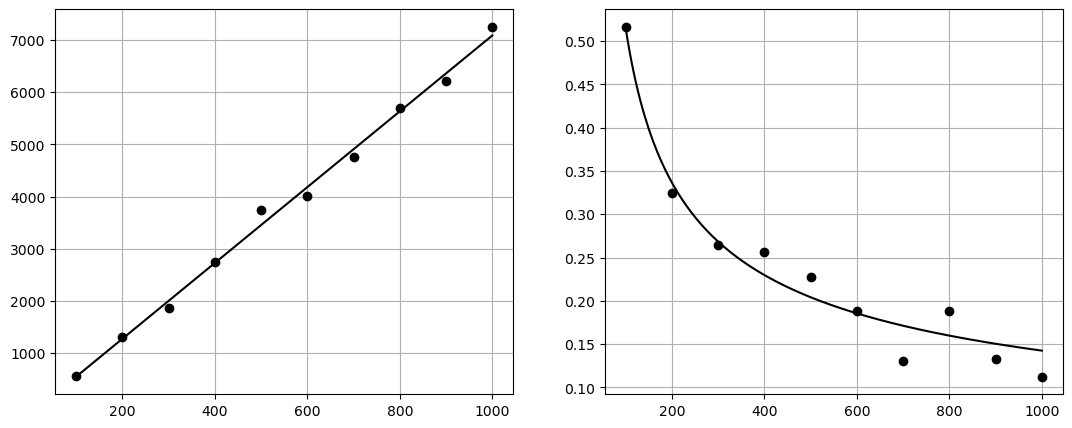

In [ ]:
# Ячейка № 7

# вычисление и визуализация значений
# зависимостей времени релаксации статистической
# системы из начального состояния
# в равновесное состояние и
# величины относительной флуктуации
# от числа частиц статистической системы

# задание массива, содержащего
# значения числа частиц статистической системы
N_Particle = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000], dtype="int")
N_p = len(N_Particle)

# инициализация массива, используемого для
# для размещения значений относительных флуктуаций
# значений числа частиц, находящихся в левой половине ящика
dZ = np.zeros(len(N_Particle))
Tau = np.zeros(len(N_Particle), dtype="int")
x = np.linspace(0, N_Step + 1, N_Step + 1)

# вычисление значений относительных флуктуаций
# для заданных значений числа частиц
# моделируемой статистической системы
for i in range(N_p):
    # вычисление ансамбля значений
    # зависимости <<число частиц
    # в левой половине ящика от времени>>
    # для данного числа частиц
    # моделируемой статистической системы
    E = Ensamble(N_Trial, N_Particle[i], N_Step)

    # вычисление средней по ансамблю реализаций
    # зависимости <<число частиц в
    # левой половине ящика от времени>>
    mean_Ensambele = np.mean(E, axis=1)

    # вычисление коэффициентов функции вида a*np.exp(-b*t) + c
    # в соответствии с методом наименьших квадратов
    Coeffs = curve_fit(
        lambda t, a, b, c: a * np.exp(-b * t) + c,
        x / 1000,
        mean_Ensambele,
        p0=(5, 0.1, 1),
    )
    Coeff2 = Coeffs[0]

    # вычисление оценки времени релаксации
    # статистической системы из начального состояния
    # в равновесное состояние
    dN = abs(N_Particle[i] / 2 - Coeff2[2]) / (N_Particle[i] / 2)

    Tau[i] = int(-np.log(dN / Coeff2[0]) / (Coeff2[1] / 1000))

    # вычисление флуктуаций числа частиц,
    # находящихся в левой половине ящика,
    # статистической системы, находящейся
    # в равновесном состоянии

    dZ[i] = np.std(mean_Ensambele[Tau[i] : N_Step] - N_Particle[i] / 2) / (
        N_Particle[i] / 2
    )

# визуализация значений
# зависимостей времени релаксации статистической
# системы из начального состояния
# в равновесное состояние и
# величины относительной флуктуации
# от числа частиц статистической системы и
# аппроксимаций данных зависимостей
fig = plt.figure(figsize=(13, 11))

# вычисление коэффициентов
# линейной аппроксимации
# зависимости времени релаксации
# статистической системы
# в состояние равновесия
# от числа частиц статистической системы
Coeff_Tau = curve_fit(lambda t, a, b: a * t + b, N_Particle, Tau)
Coeff_Tau2 = Coeff_Tau[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func_Tau(x, a, b):
    return a * x + b


# вычисление значений аппроксимирующей функции
y = func_Tau(N_Particle, Coeff_Tau2[0], Coeff_Tau2[1])

ax = plt.subplot(2, 2, 1)
plt.plot(N_Particle, Tau, "ok")
plt.plot(N_Particle, y, color="black")
plt.grid(True)

# вычисление коэффициентов a, b, c
# аппроксимации функцией вида a * sqrt(b * x + c)
# зависимости относительных флуктуаций от
# числа частиц статистической системы
Coeff_dZ = curve_fit(lambda t, a, b, c: a / (b * t + c), N_Particle, dZ**2)

Coeff_dZ2 = Coeff_dZ[0]


# вычисление значений аппроксимирующей функции
x = np.linspace(N_Particle[0], N_Particle[N_p - 1], 200)
y = func_dZ(x, Coeff_dZ2[0], Coeff_dZ2[1], Coeff_dZ2[2])

ax = plt.subplot(2, 2, 2)
plt.plot(N_Particle, dZ * 100, "ok")
plt.plot(x, np.sqrt(y) * 100, color="black")
plt.grid(True)

plt.show()